# 水印 Mask 可视化

运行外部测试集的成对推理，展示原图、Clean Candidate、Mask 概率图和 Overlay。

In [ ]:
from pathlib import Path
import sys
PROJECT_DIR=Path.cwd().resolve()
for parent in (PROJECT_DIR, *PROJECT_DIR.parents):
    if (parent/'mask-model').is_dir() and (parent/'0-数据').is_dir():
        PROJECT_DIR=parent
        break
else:
    raise FileNotFoundError('找不到项目根目录，请在项目目录内启动 Jupyter')
MODEL_DIR=PROJECT_DIR/'mask-model'
DATA_ROOT=PROJECT_DIR/'0-数据'
RUN_DIR=MODEL_DIR/'handoff'
CHECKPOINT=RUN_DIR/'weights/watermark_mask.pt'
OUTPUT_ROOT=RUN_DIR/'external_notebook'
if not CHECKPOINT.is_file():
    raise FileNotFoundError(f'找不到模型权重: {CHECKPOINT}')
sys.path.insert(0,str(MODEL_DIR))
print('project:',PROJECT_DIR)
print('checkpoint:',CHECKPOINT)
print('output:',OUTPUT_ROOT)

project: /home/lyq/projects/图像去水印
checkpoint: /home/lyq/projects/图像去水印/mask-model/handoff/weights/watermark_mask.pt
output: /home/lyq/projects/图像去水印/mask-model/handoff/external_notebook


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from evaluate_external_paired_test import match_category
from infer import predict_full_resolution
from models import paired_model_from_checkpoint

# 推理参数：显存不足时将 batch_size 改为 1。
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TILE,OVERLAP,THRESHOLD=512,64,0.5
MAX_IMAGES_PER_CATEGORY=3
checkpoint=torch.load(CHECKPOINT,map_location='cpu',weights_only=False)
model,architecture=paired_model_from_checkpoint(checkpoint)
model=model.to(DEVICE).eval()
print(f'architecture={architecture}, epoch={checkpoint.get("epoch")}, best_iou={checkpoint.get("best_iou")}, device={DEVICE}')

architecture=difference_gate, epoch=27, best_iou=0.7028675537605059, device=cuda


In [3]:
# 自动读取同时存在原图目录和对比结果目录的测试类别。
CATEGORIES=sorted(p.name for p in (DATA_ROOT/'对比结果').iterdir() if p.is_dir() and (DATA_ROOT/p.name).is_dir())
records=[]
for category in CATEGORIES:
    current=match_category(DATA_ROOT/category,DATA_ROOT/'对比结果'/category,OUTPUT_ROOT/'candidates'/category)
    if MAX_IMAGES_PER_CATEGORY>0: current=current[:MAX_IMAGES_PER_CATEGORY]
    records.extend(current); print(category,len(current))
results=[]
for index,record in enumerate(records,1):
    with Image.open(record['source']) as f: source=f.convert('RGB')
    with Image.open(record['candidate']) as f: candidate=f.convert('RGB')
    probability=predict_full_resolution(model,source,candidate,DEVICE,tile=TILE,overlap=OVERLAP,batch_size=1)
    out=OUTPUT_ROOT/record['category']; out.mkdir(parents=True,exist_ok=True)
    pp=out/f"{record['id']}_probability.png"; mp=out/f"{record['id']}_mask.png"; op=out/f"{record['id']}_overlay.jpg"
    binary=probability>=THRESHOLD
    Image.fromarray(np.round(probability*65535).astype(np.uint16)).save(pp)
    Image.fromarray(binary.astype(np.uint8)*255).save(mp)
    overlay=np.asarray(source,dtype=np.float32)/255.; overlay[binary]=.45*overlay[binary]+.55*np.array([1.,0.,0.])
    Image.fromarray(np.round(overlay.clip(0,1)*255).astype(np.uint8)).save(op,quality=92)
    results.append({**record,'probability':str(pp),'mask':str(mp),'overlay':str(op),'mask_fraction':float(binary.mean()),'p99_probability':float(np.percentile(probability,99))})
    print(f"[{index}/{len(records)}] {record['category']}/{record['id']} mask={binary.mean()*100:.2f}%")
with (OUTPUT_ROOT/'results.jsonl').open('w',encoding='utf-8') as f:
    for r in results: f.write(json.dumps(r,ensure_ascii=False)+'\n')
pd.DataFrame(results)[['category','id','match_cost','p99_probability','mask_fraction']]

日常图片水印 3
UNMATCHED /home/lyq/projects/图像去水印/0-数据/电子文档水印/9.jpg
UNMATCHED /home/lyq/projects/图像去水印/0-数据/电子文档水印/test_0002.jpg
电子文档水印 3
试卷水印 3
[1/9] 日常图片水印/1 mask=10.49%
[2/9] 日常图片水印/2 mask=6.98%
[3/9] 日常图片水印/3 mask=12.97%
[4/9] 电子文档水印/1000 mask=2.04%
[5/9] 电子文档水印/1001 mask=3.91%
[6/9] 电子文档水印/1002 mask=2.64%
[7/9] 试卷水印/FCF7C9D6-D863-4ef5-941A-660740A218B0 mask=8.55%
[8/9] 试卷水印/IMG_7323.HEIC mask=14.89%
[9/9] 试卷水印/IMG_7324.HEIC mask=6.51%


,category,id,match_cost,p99_probability,mask_fraction
0,日常图片水印,1,0.002154,0.999918,0.104850
1,日常图片水印,2,0.001032,0.999725,0.069755
2,日常图片水印,3,0.002053,0.995143,0.129733
3,电子文档水印,1000,0.004063,0.964394,0.020353
4,电子文档水印,1001,0.003989,0.999048,0.039136
5,电子文档水印,1002,0.003455,0.996044,0.026369
6,试卷水印,FCF7C9D6-D863-4ef5-941A-660740A218B0,0.001951,0.998018,0.085464
7,试卷水印,IMG_7323.HEIC,0.004469,0.997348,0.148937
8,试卷水印,IMG_7324.HEIC,0.004580,0.994291,0.065111


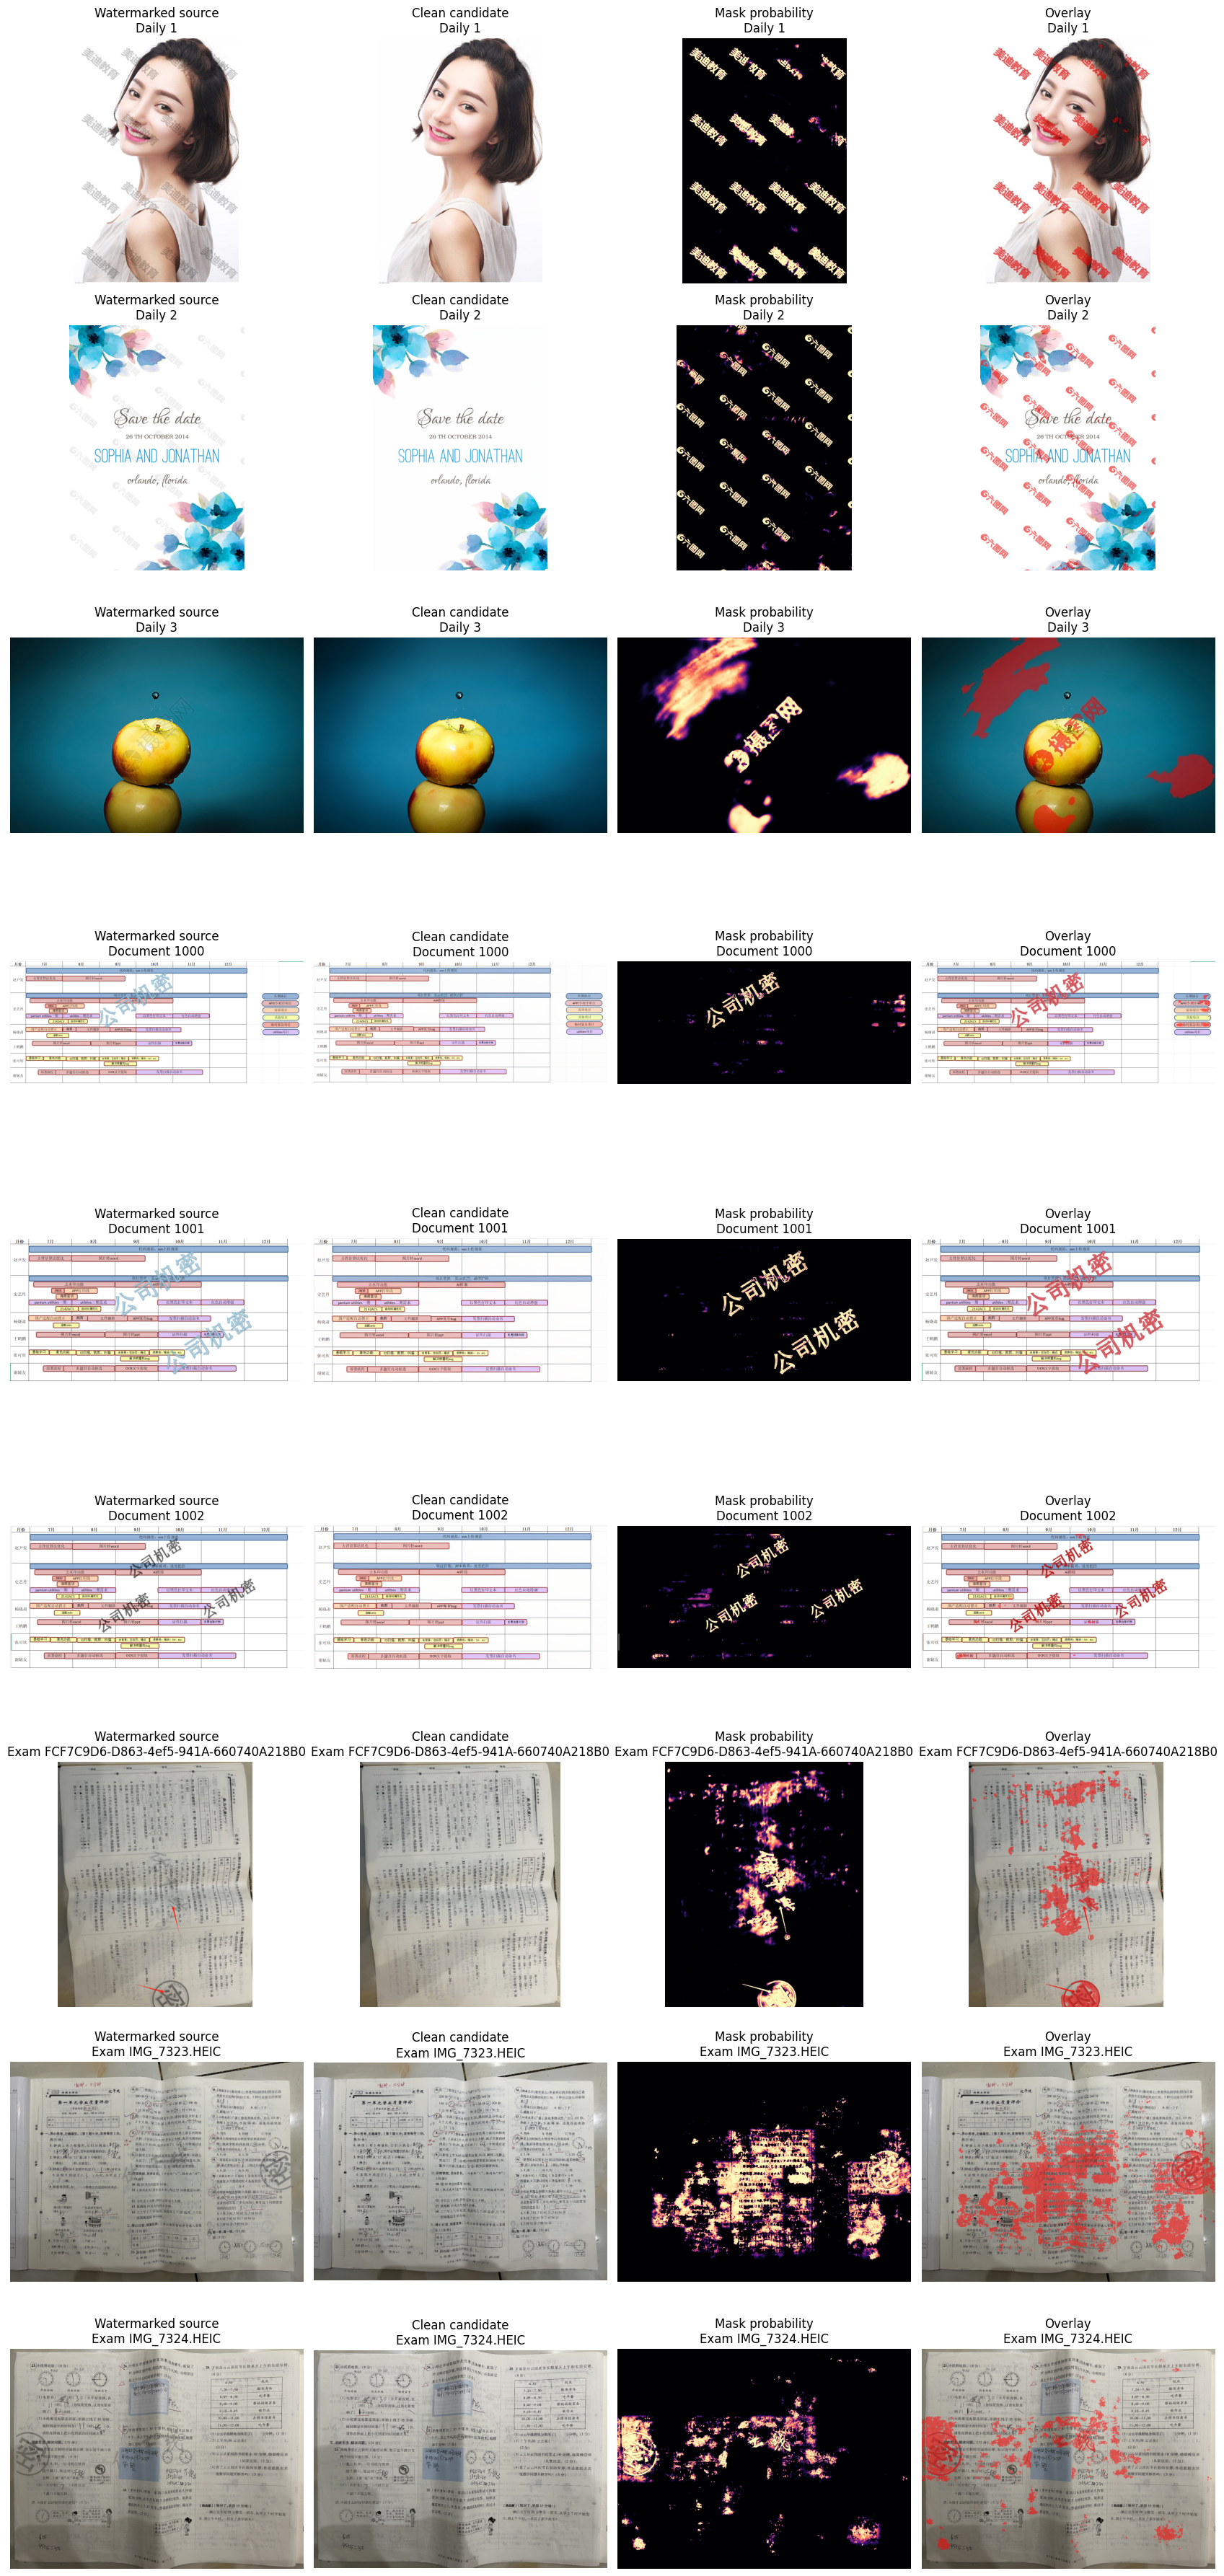

In [4]:
def show_results(limit=6,category=None):
    selected=[r for r in results if category is None or r['category']==category][:limit]
    if not selected: print('没有可显示的结果'); return
    names={'日常图片水印':'Daily','电子文档水印':'Document','试卷水印':'Exam'}
    fig,axes=plt.subplots(len(selected),4,figsize=(17,4*len(selected))); axes=np.atleast_2d(axes)
    for row,r in enumerate(selected):
        with Image.open(r['source']) as f: source=f.convert('RGB')
        with Image.open(r['candidate']) as f: candidate=f.convert('RGB')
        with Image.open(r['probability']) as f: probability=np.asarray(f,dtype=np.float32)/65535.
        with Image.open(r['overlay']) as f: overlay=f.convert('RGB')
        for col,(image,title) in enumerate(((source,'Watermarked source'),(candidate,'Clean candidate'),(probability,'Mask probability'),(overlay,'Overlay'))):
            axes[row,col].imshow(image,cmap='magma' if col==2 else None,vmin=0 if col==2 else None,vmax=1 if col==2 else None)
            axes[row,col].set_title(f"{title}\n{names.get(r['category'],'Test')} {r['id']}"); axes[row,col].axis('off')
    plt.tight_layout(); plt.show()
show_results(limit=9)

结果保存在 `mask-model/runs/external_notebook/`。`MAX_IMAGES_PER_CATEGORY=0` 可运行每类全部图片，`THRESHOLD` 可调整二值 mask 阈值。